## Points to improve
- ~make a class object for mapping floods and push everything in the backend.~
- ~dry dates should be taken from the attributes of the shapefile.~
- ~processed images (tile) should be stored in a json file.~
- ~flood map tiles have a gap in between. Polygon dissolve will leave gap.~
- ~store polygon-wise cell-level mean and std values or all values in the dry period? If doing the first option, how to update with new images? No need to update for IFMIAP and have a static cell-level mean and std values?~
- ~flood maps are vertically flipped~
- ~In the json, if the id already exists, do not overwrite it.~
- ~sort JSON keys and values~
- ~after mean and std computation, check for dem~
    - ~clip and store the dem file for all given AOIs.~
    - ~If the clipped dem*.nc file exist for that aoi, don't redo, else do.~
- ~define a period for which wet scenes will be downloaded~
- ~map floods for each new scene for each tile~
    - ~if area of floods is GT certain threshold, then store the flood map, else skip~
    - ~write in a json file that for this aoi, the scene has already been evaluated for flood cells (have dry years in the filename)~
- ~add year range in json file name~
- ~add years in the file name in the exported .nc file~
- ~work in local UTM projection~
    - add ~elevation and~ slope mask to the workflow
- ~flood raster smoothing instead of vector buffer (required only if there are gaps between tiles)~
- ~add start and end year of dry period to the flood extent files~
- push low level code to utils and other relevant modules
- make sure other functions make use of the preprocessing.clip_xarray_using_id function
- ~make subfolders in the output folder for mean_std and flood~
- remove dependency on INDIA_GRID_SHAPEFILE_PATH defined in utils
- add a self.flush_files method to delete all the files created by the instance of class
- ~dissolve and merge shapefile date wise -- in the end~
- while debugging, check for floods in other parts of the country too
- the utils.merge_flood_gdfs is sensitive to underscores in the file path, folder names also have underscores
- ~add start and end wet years in the final_output files~

## Current roadblock
- we are reprojecting the tiles and the images to local UTM zones by estimating that from the downloaded satellite image but that is complicating things. For instance one satellite image can fall in two separate UTM zones but still force all the tiles that it falls on to have same utm zone. A better way is to have utm zone crs values stored in the attributes of the shapefile.

## Interesting points
- The read_reproject function processed 84 scenes in 9 min 28 sec on local computer at overview level 3.
- reprojecting the image twice in the preprocessing.read_reproject function because estimate_utm_crs is giving wrong utm zone the first time, so we are doing twice and then it is working fine

In [1]:
from ifmiap import flood_mapper
from ifmiap import utils

/opt/homebrew/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
# create the flood mapper class
bihar_flood_mapper = flood_mapper(
    grid_shapefile = r'resources/india_utm_fishnet.gpkg',
    grid_id_list = [344, 348],
    dry_date_col = 'dry_month',
    id_col = 'ID',
    dry_years=[2019, 2020],
    dem_dir = r'../dem_for_ifmiap/',
    wet_duration = ['2022/07', '2022/08']
)

/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


DEM for tile ID 344 not found. Downloading...
DEM for tile ID 348 not found. Downloading...
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220830T122209_20220830T122234_044782_055900.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220826T002005_20220826T002030_044716_0556C3.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220823T122951_20220823T123020_044680_055589.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220818T122209_20220818T122234_044607_05530F.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220814T002004_20220814T002029_044541_0550DE.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220811T122950_20220811T123019_044505_054F9A.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220809T001157_20220809T001222_044468_054E71.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220806T122208_20220806T122233_044432_054D5E.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220802T002003_20220802T002028_044366_054B71.
Flood cells not found in 344_S1A_IW_GRDH_1SDV_20220730T122950_20220730T

/Users/pratyusht/Documents/MapSolveAI/ifmiap/ifmiap/mapfloods/__init__.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1, 1, figsize=(width / 100, height / 100))


CPU times: user 1min 49s, sys: 9.78 s, total: 1min 59s
Wall time: 8min 28s


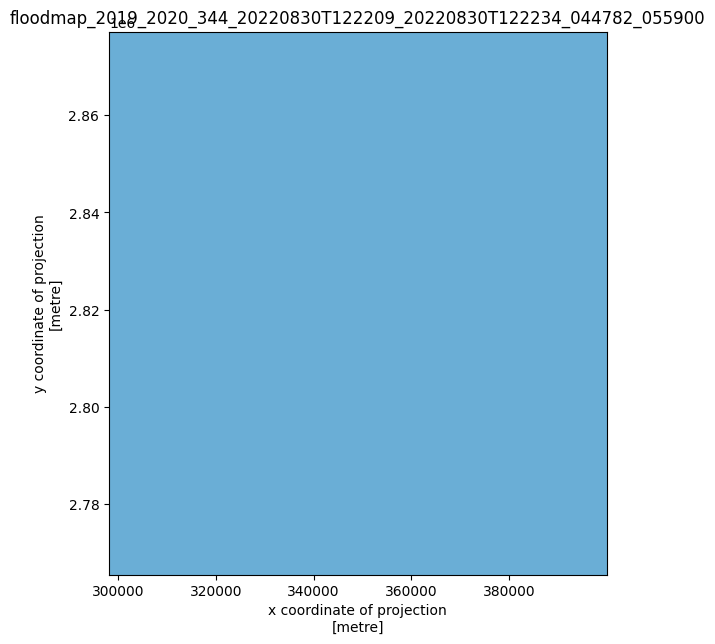

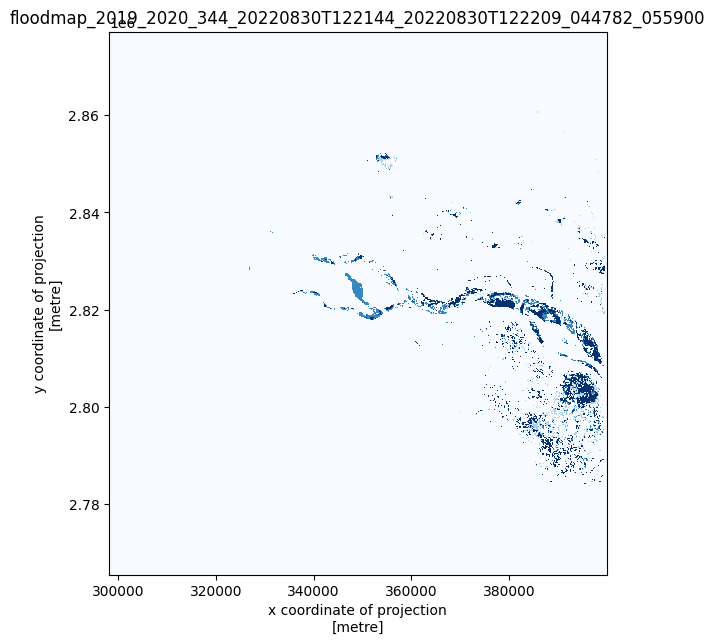

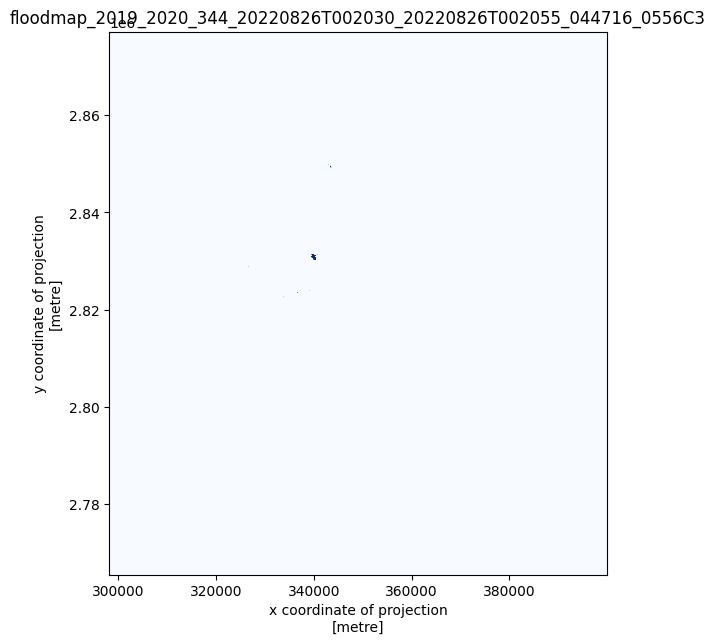

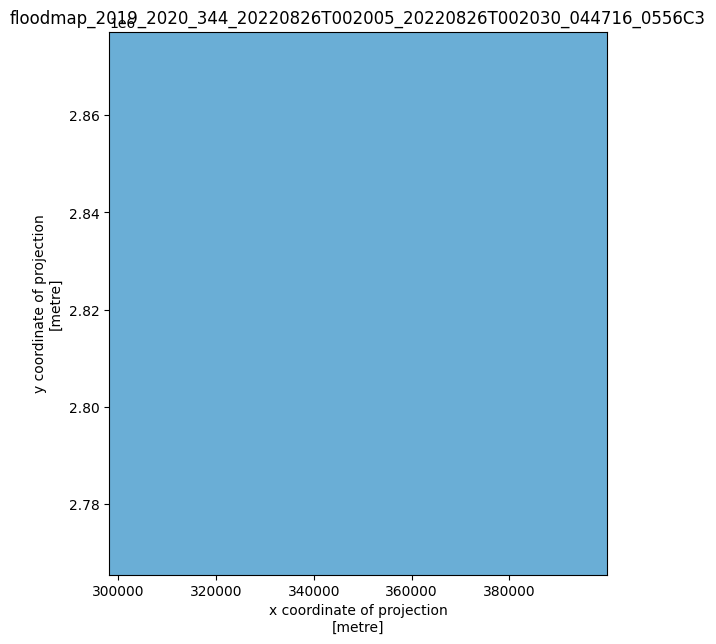

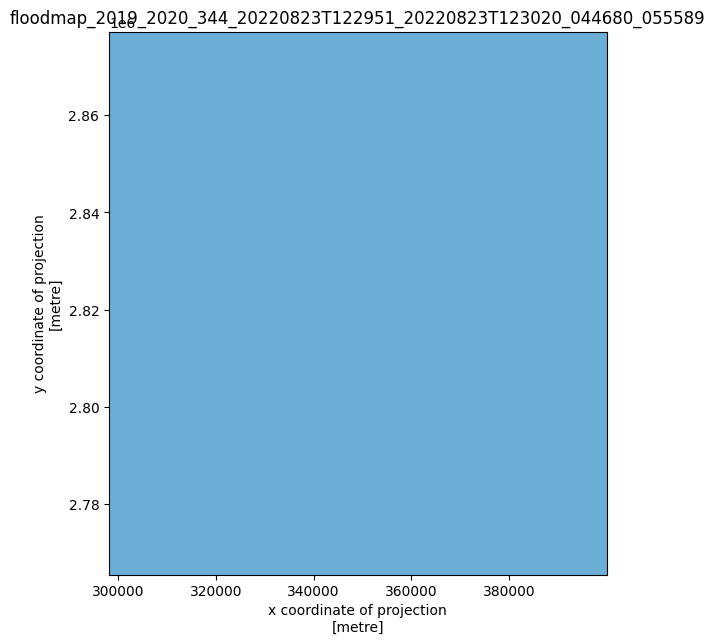

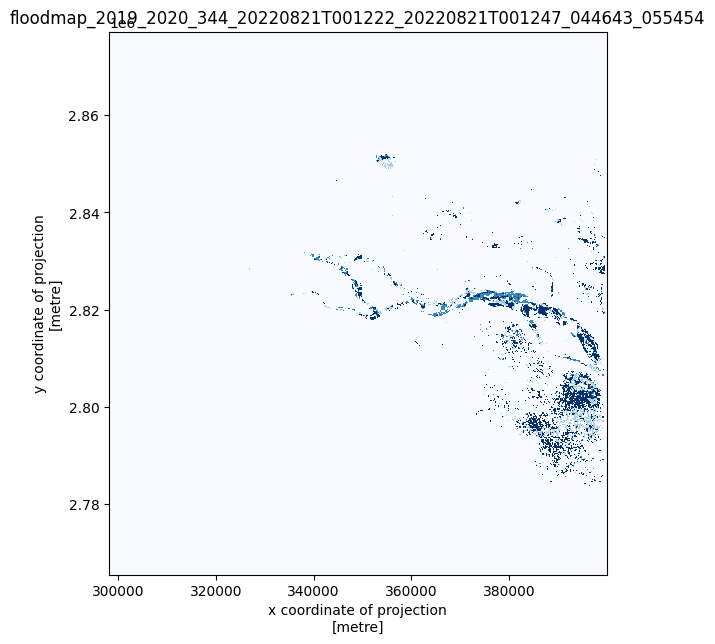

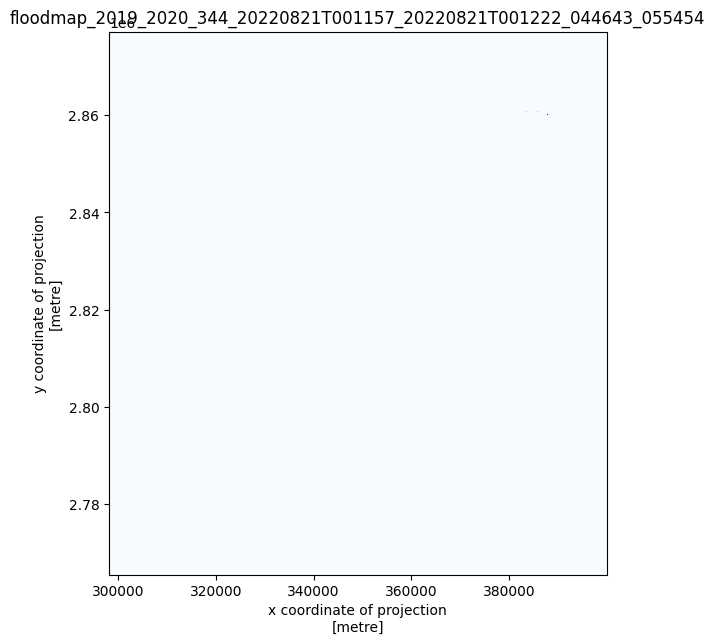

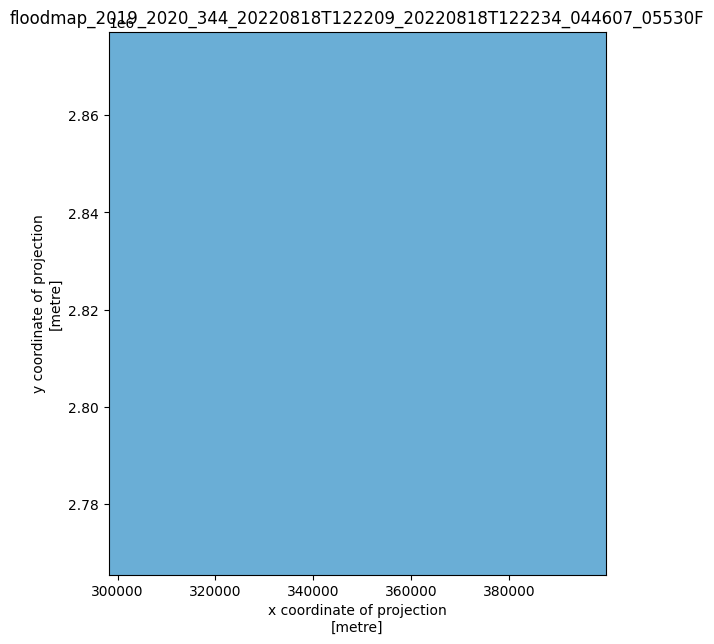

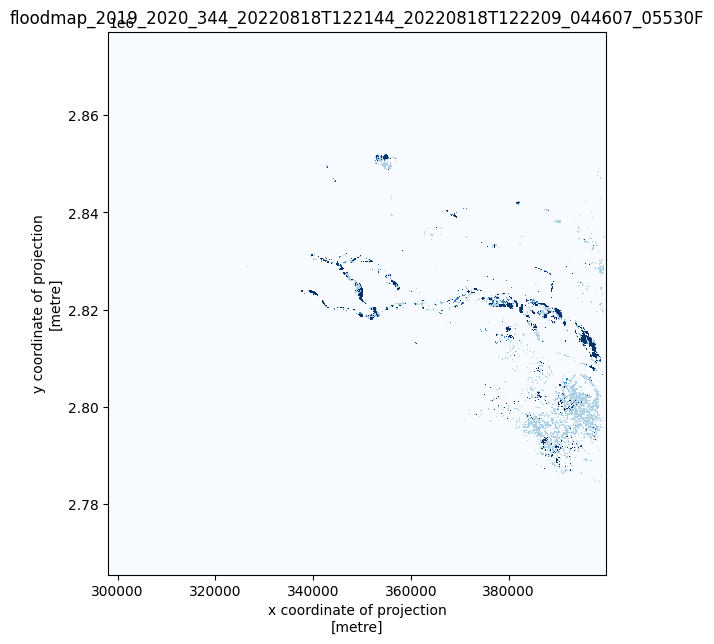

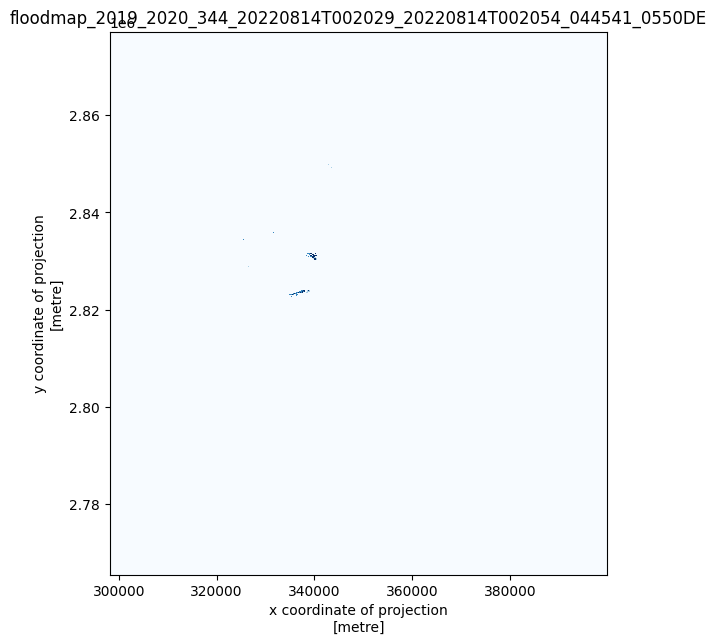

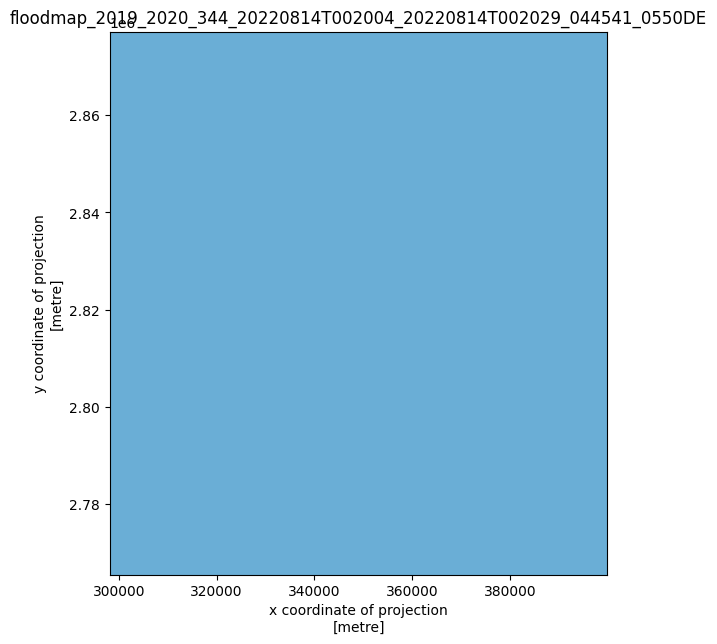

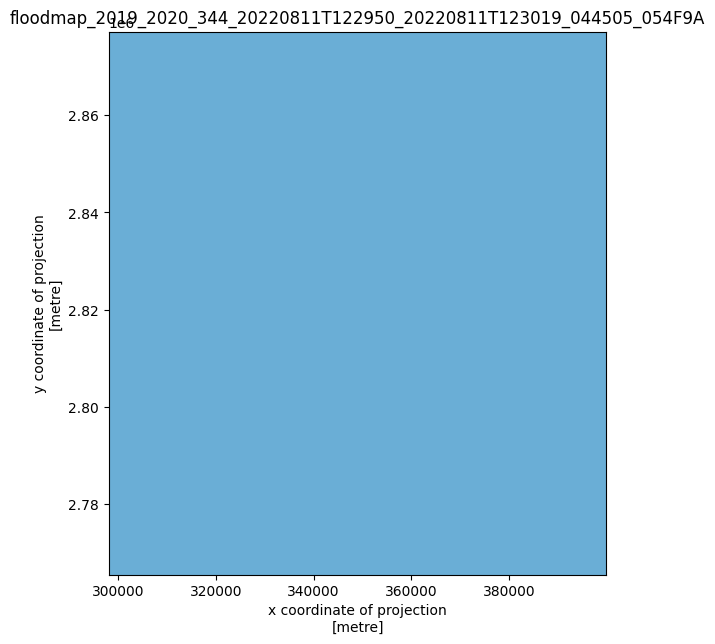

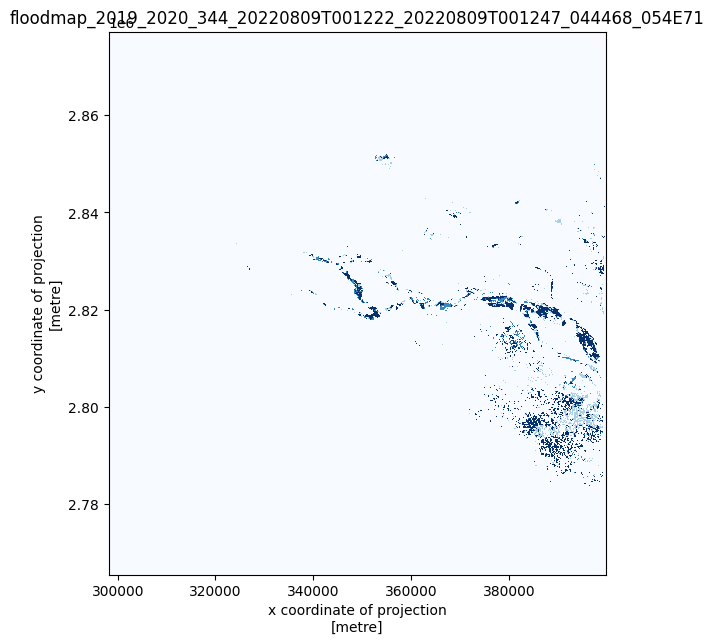

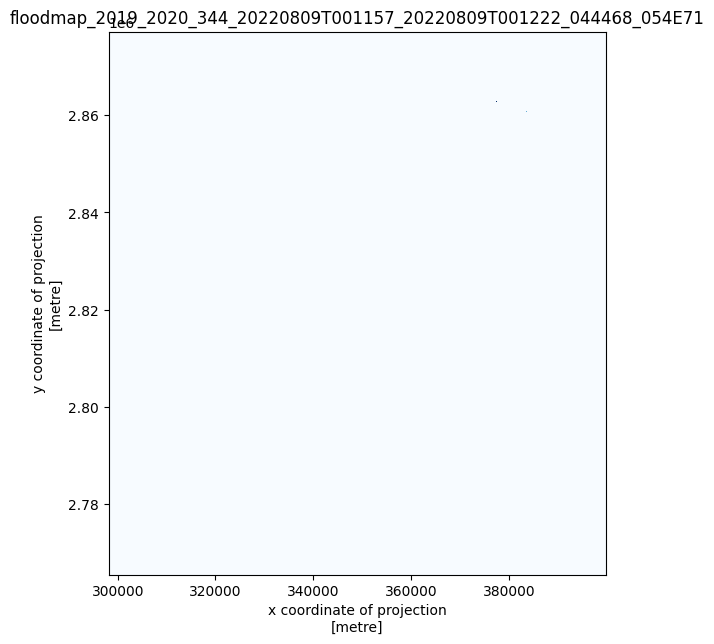

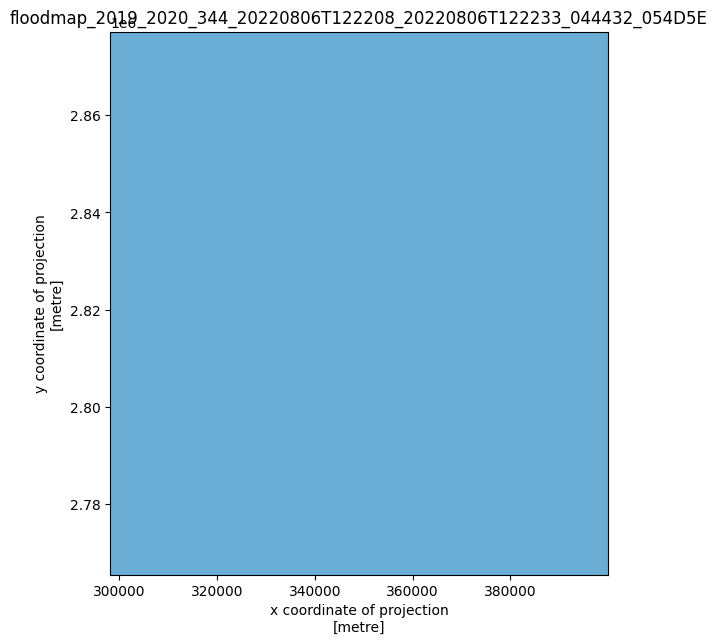

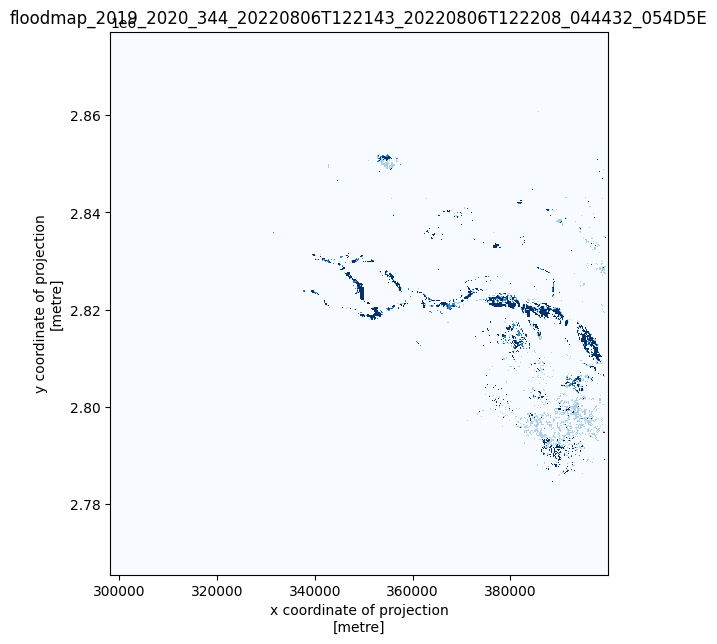

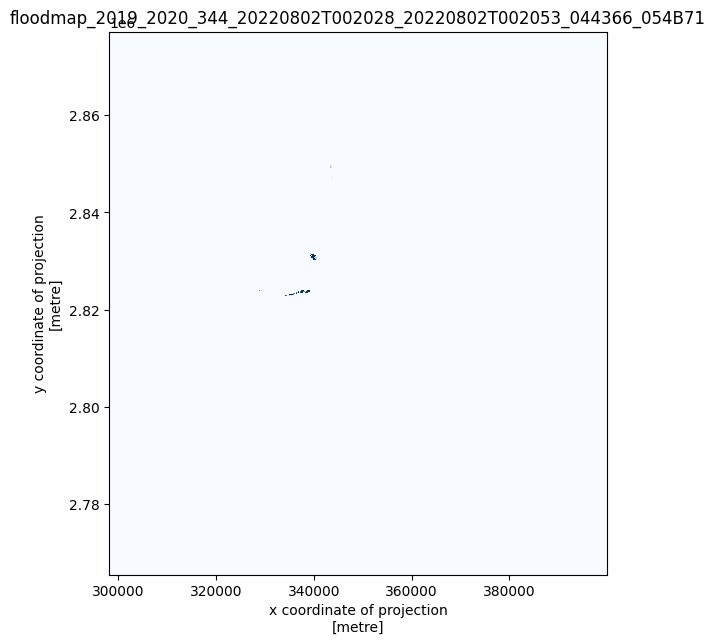

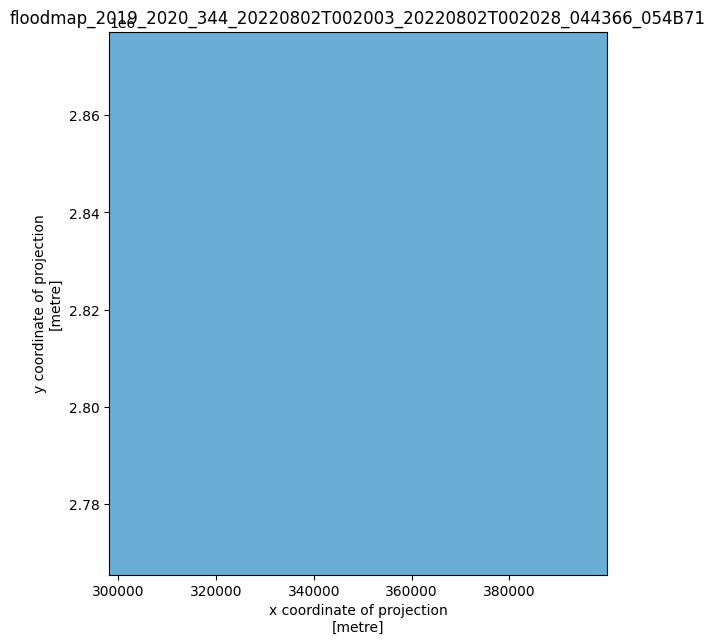

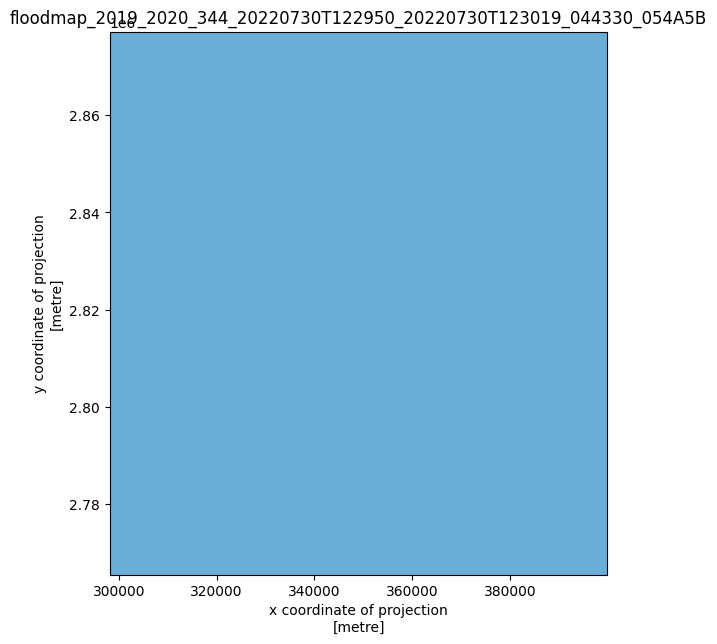

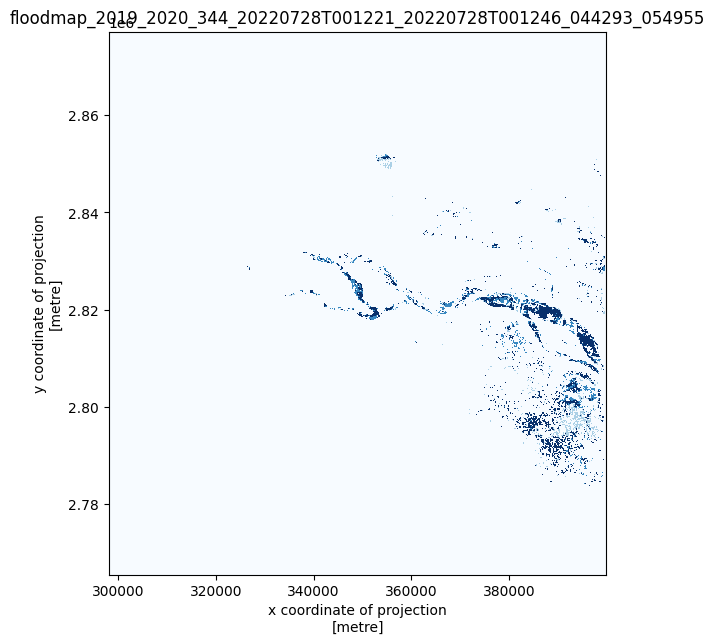

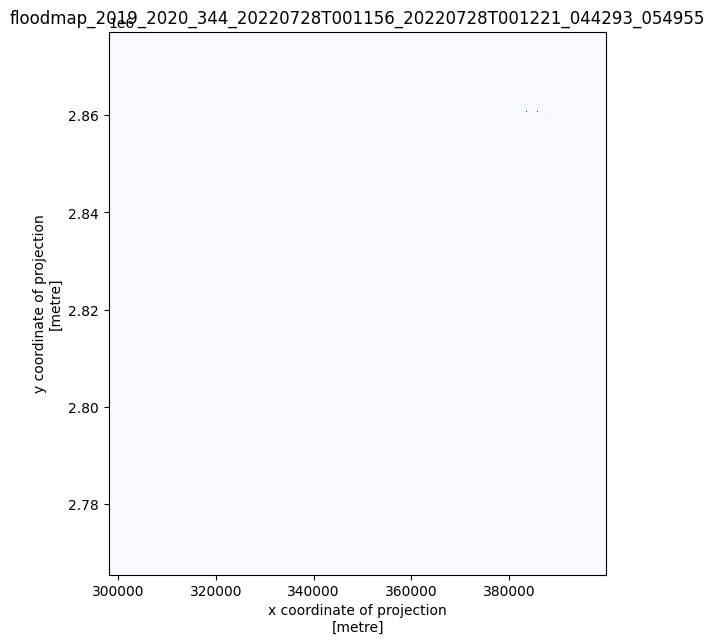

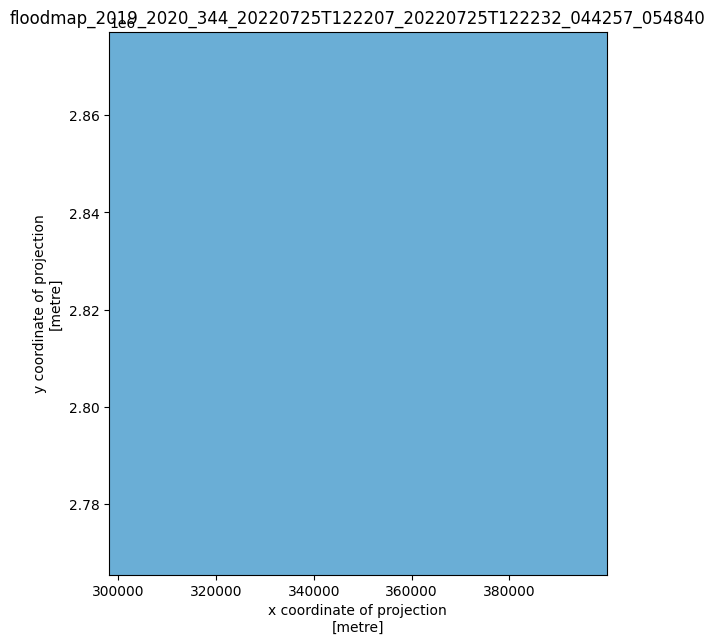

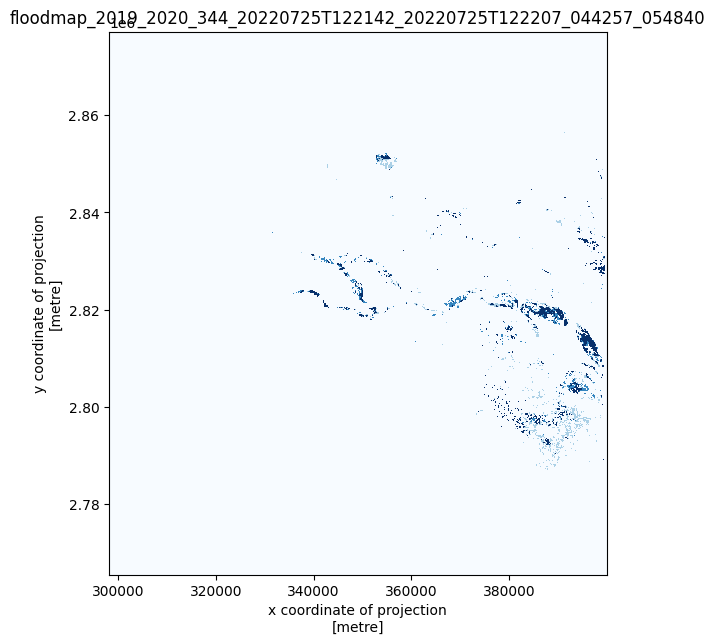

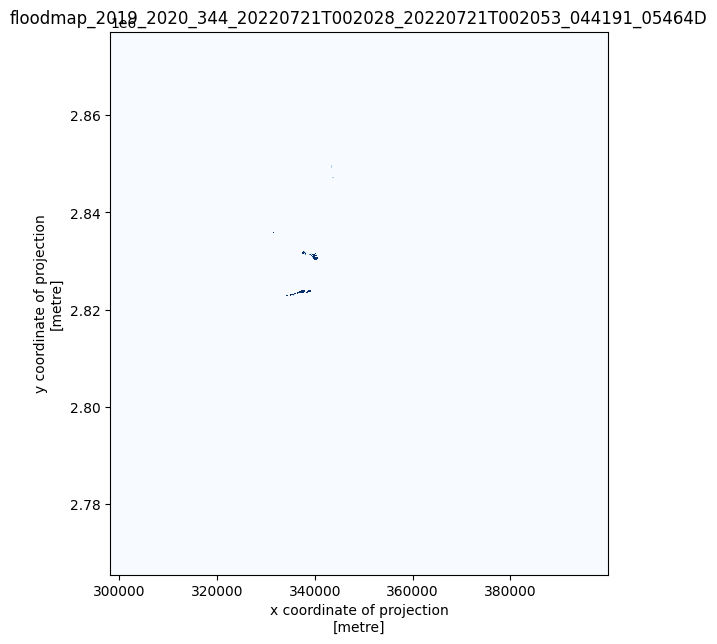

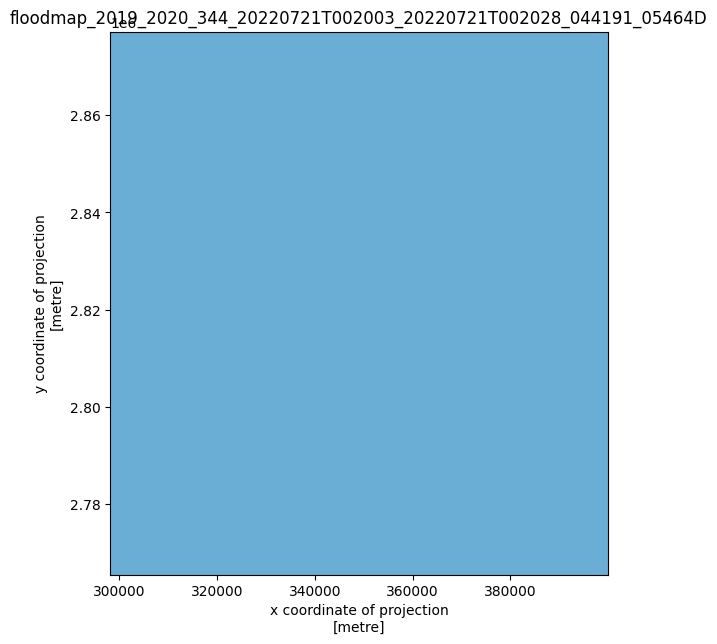

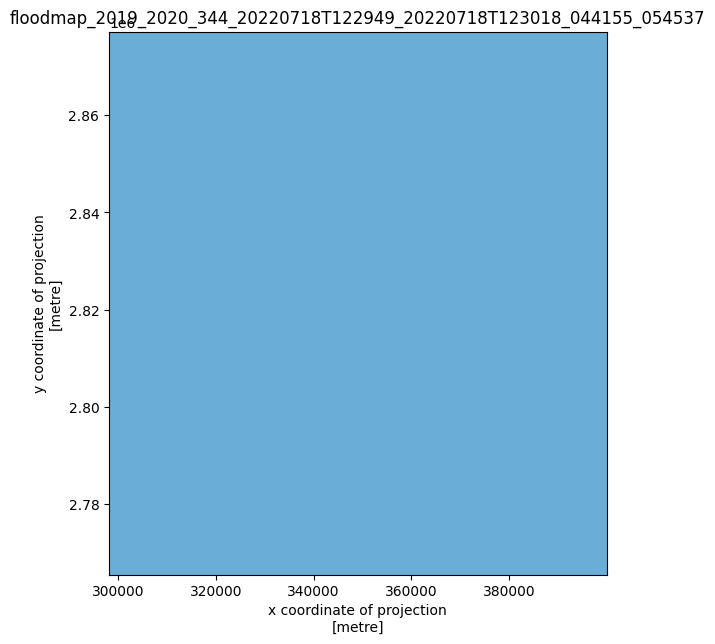

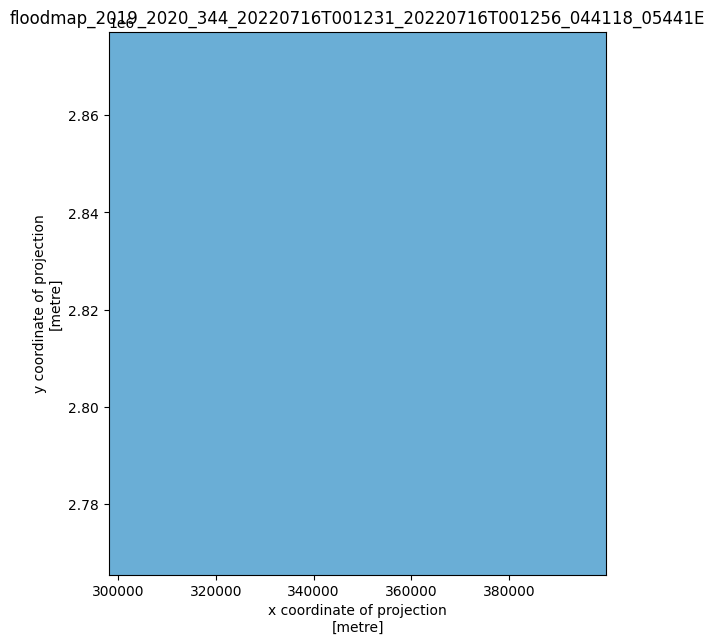

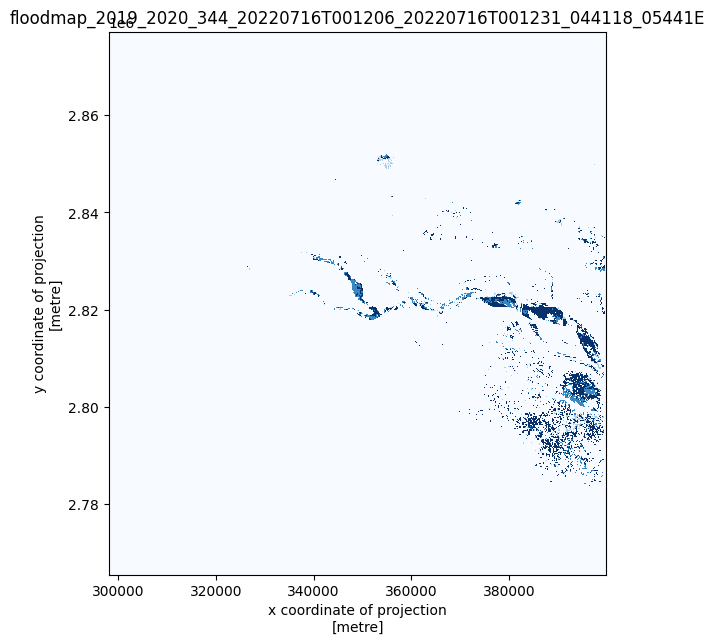

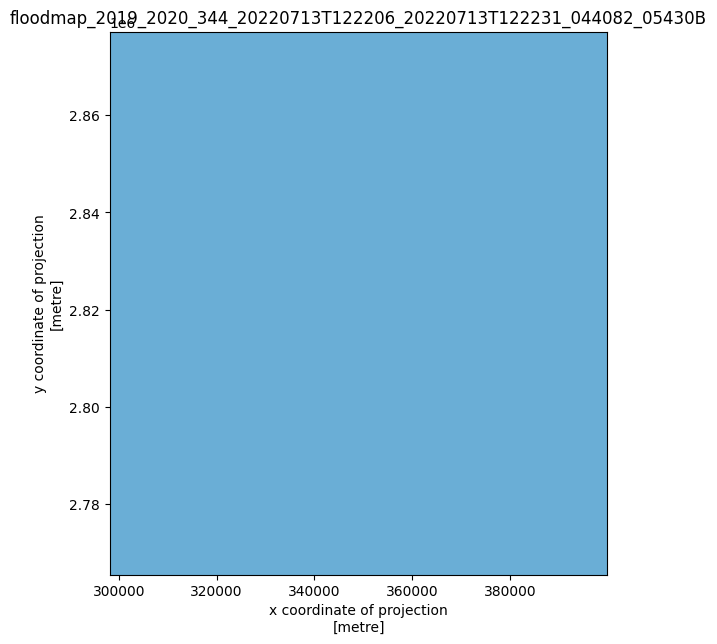

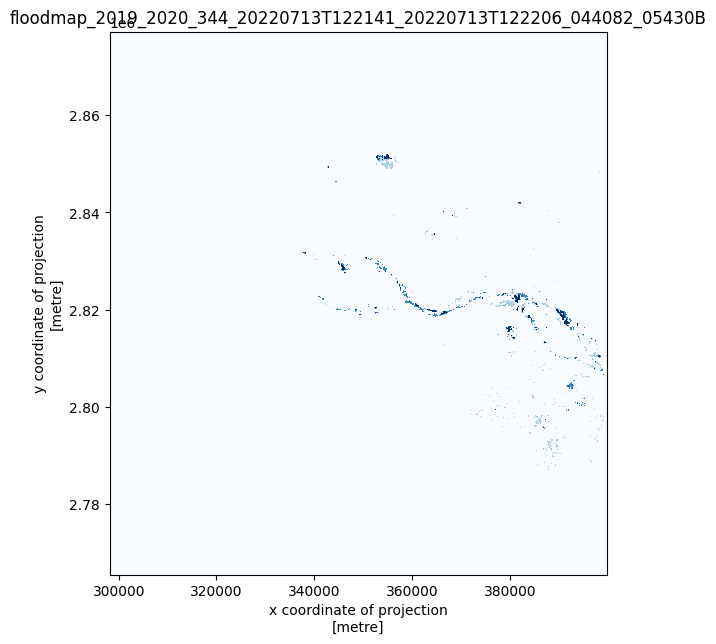

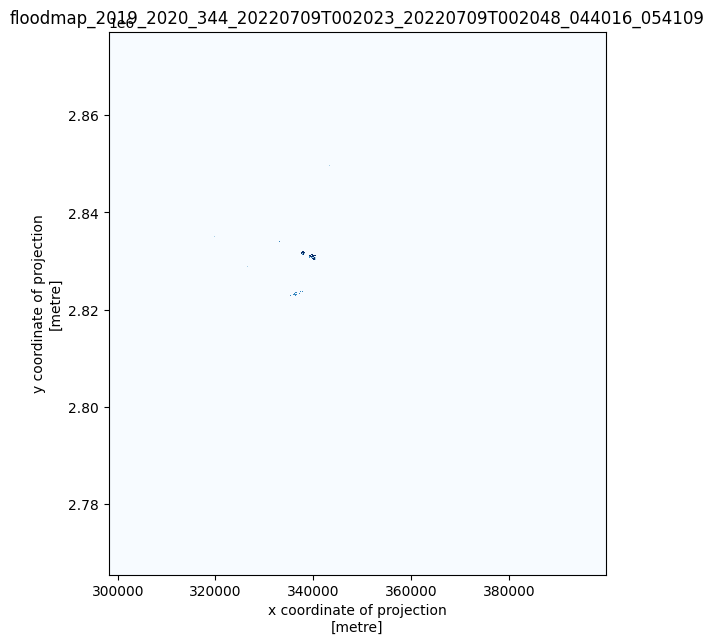

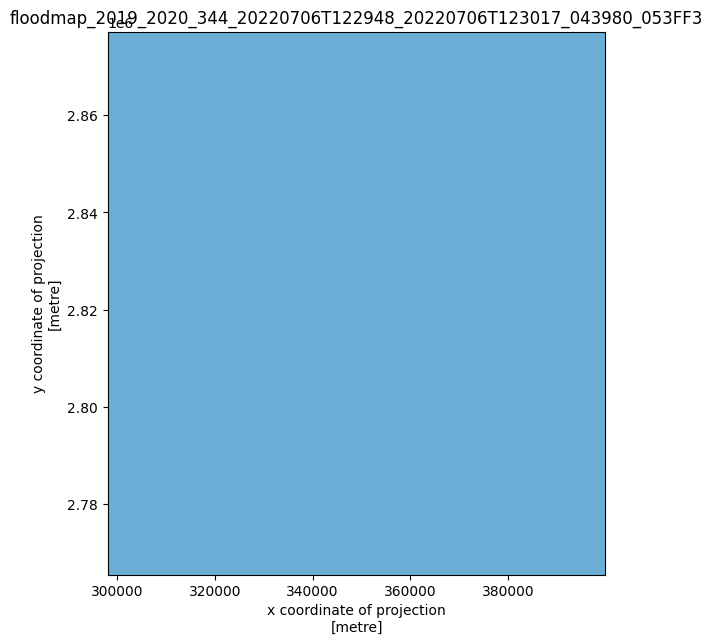

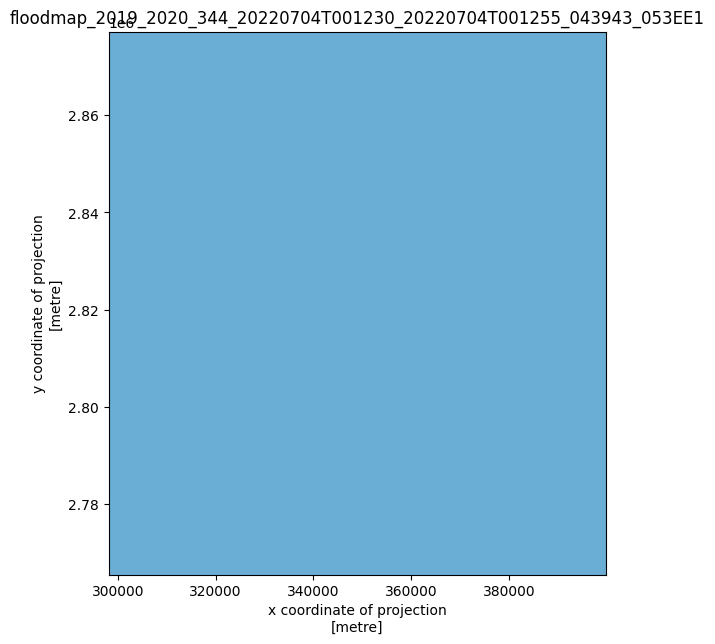

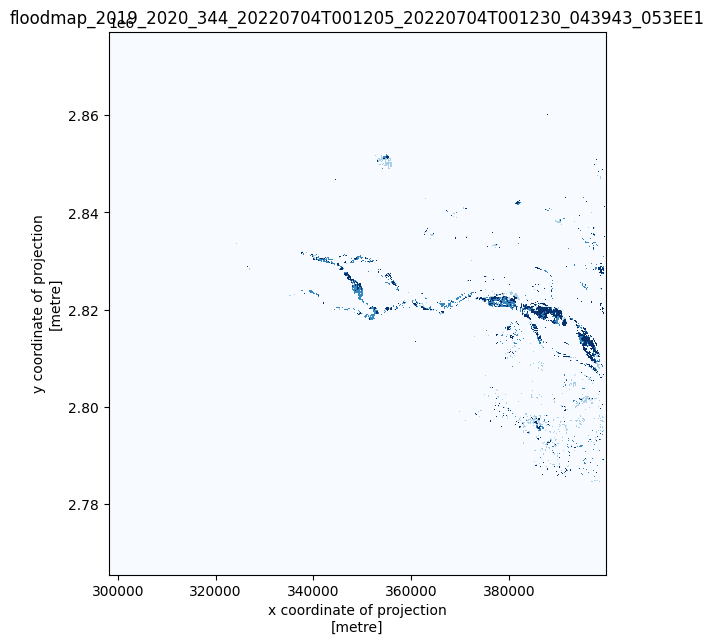

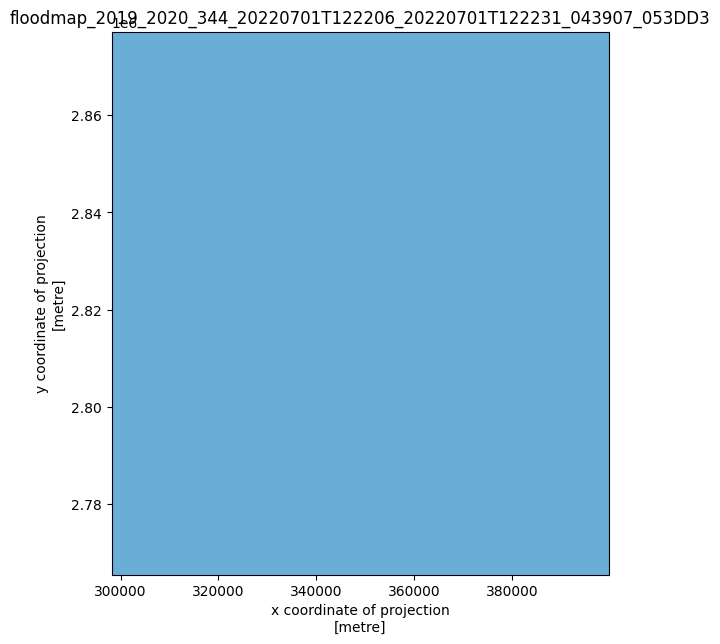

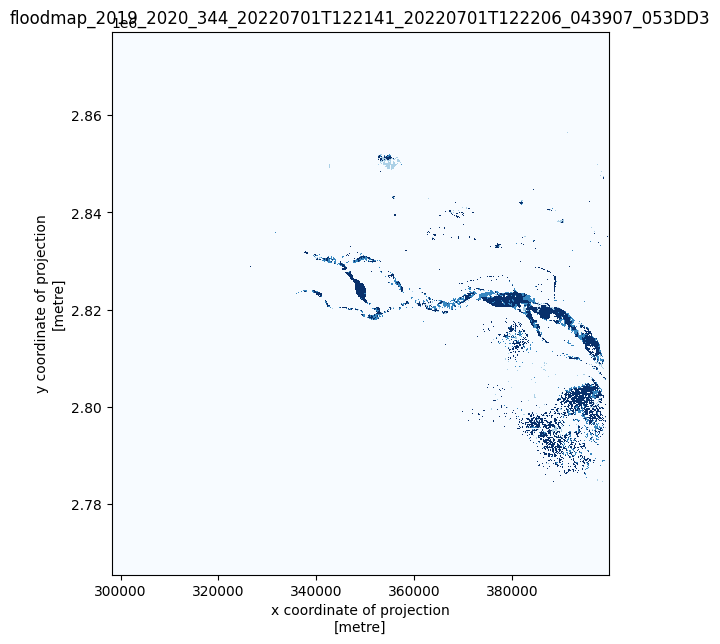

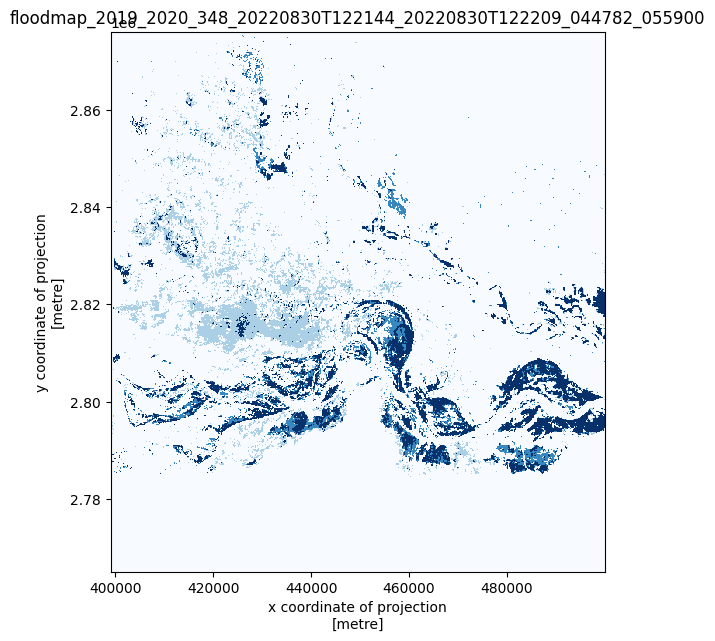

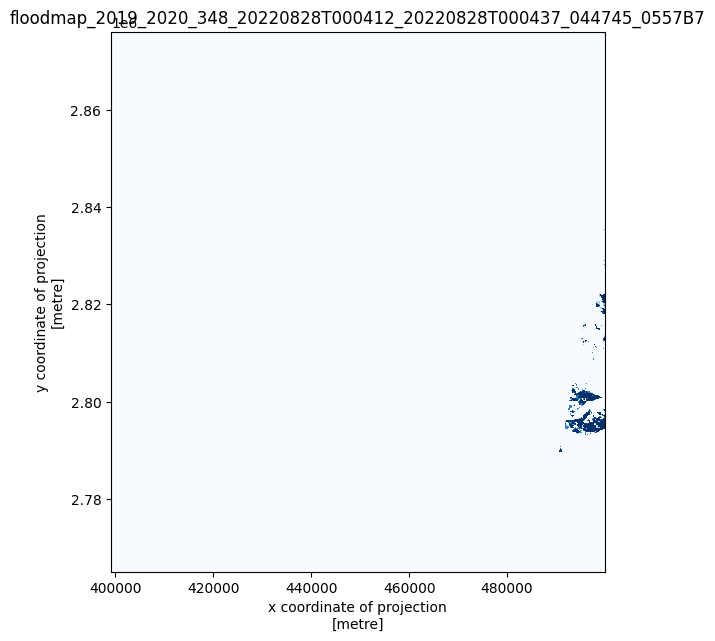

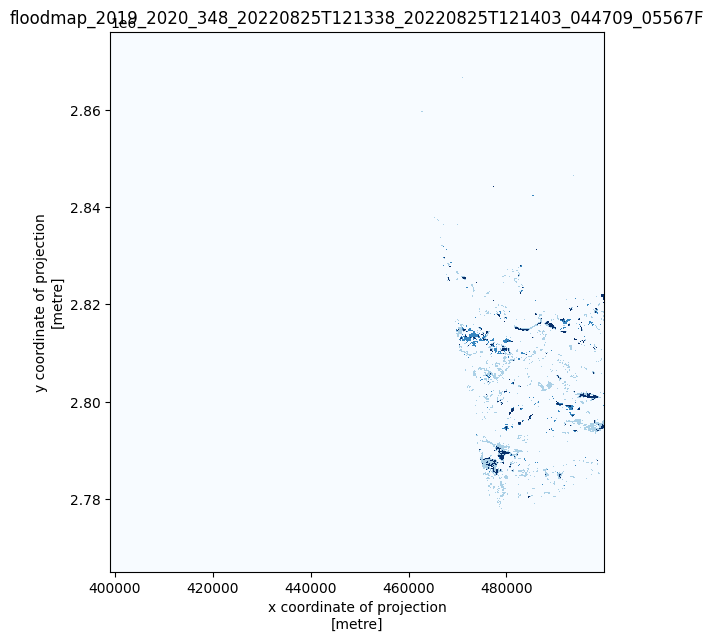

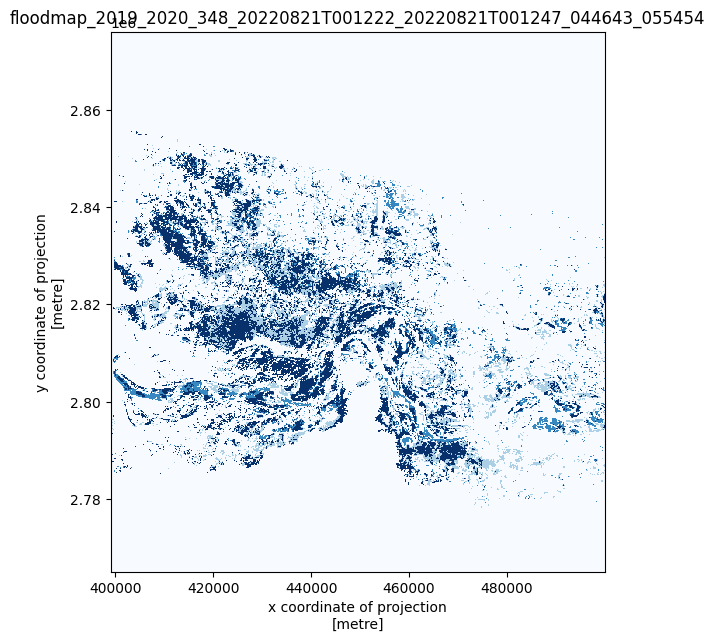

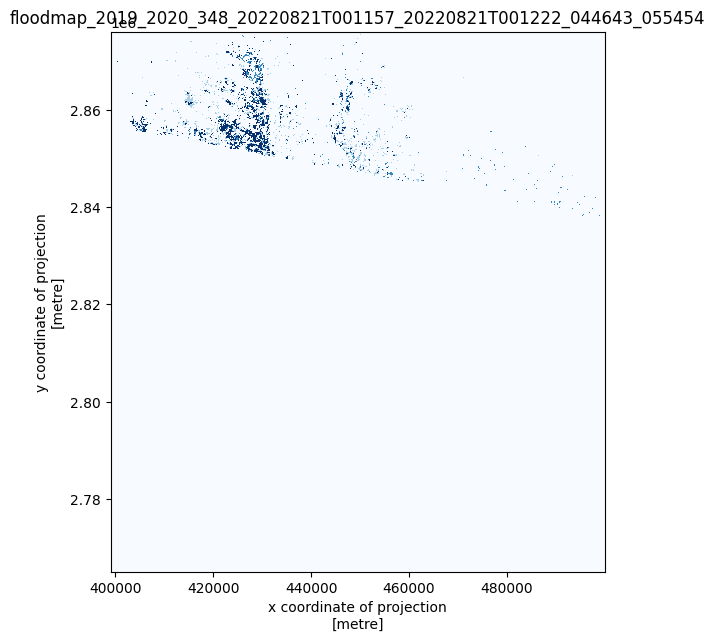

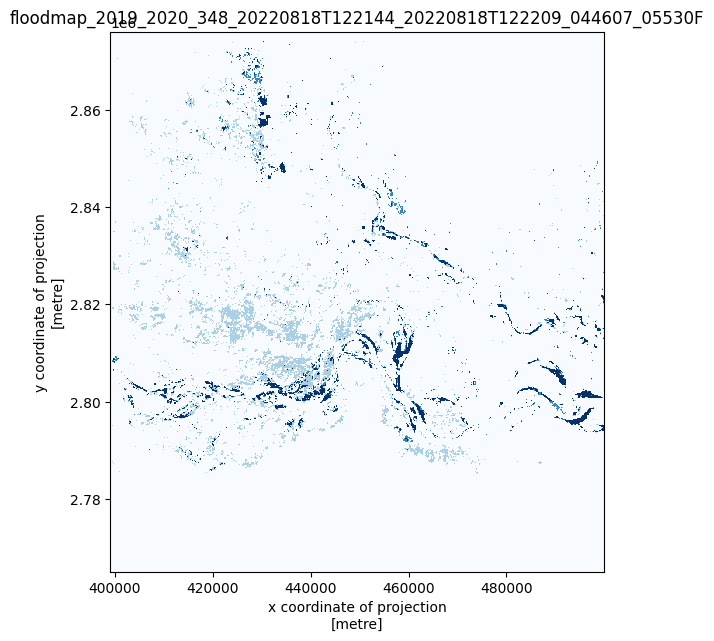

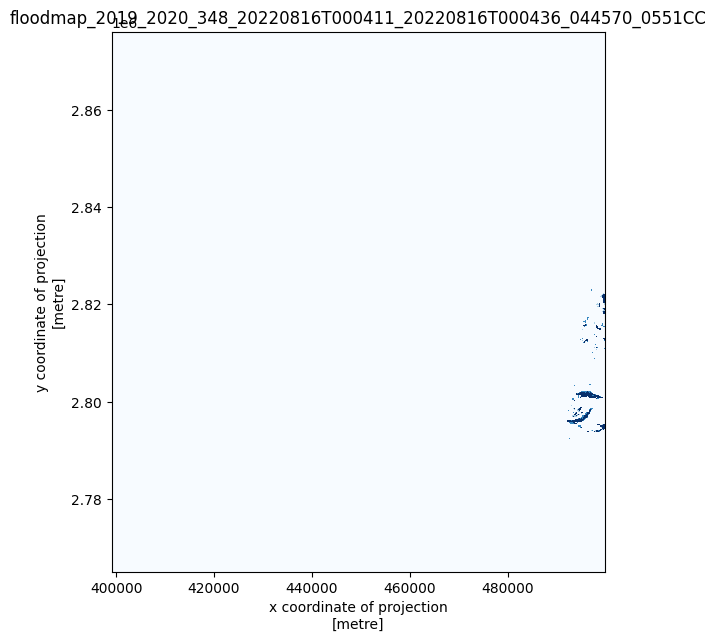

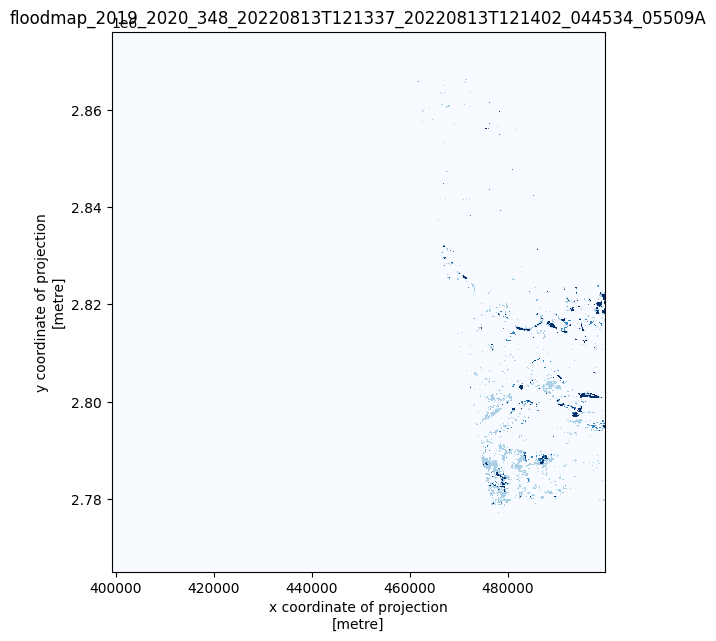

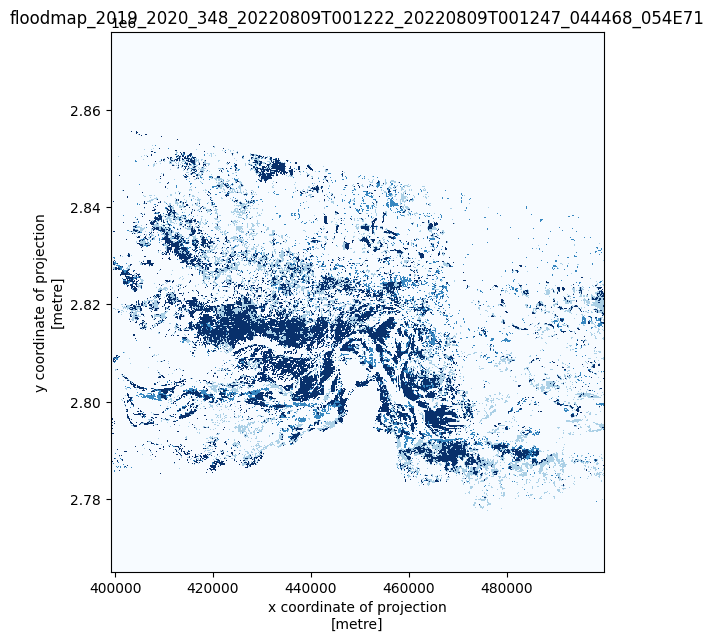

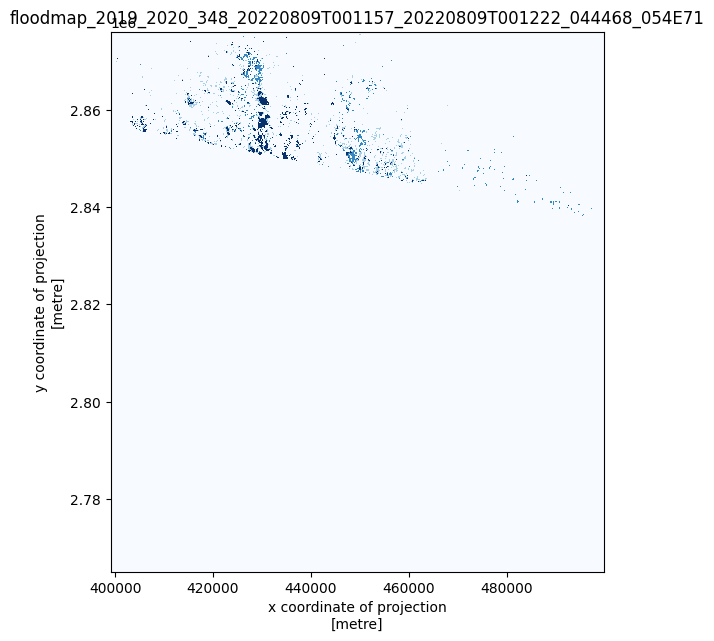

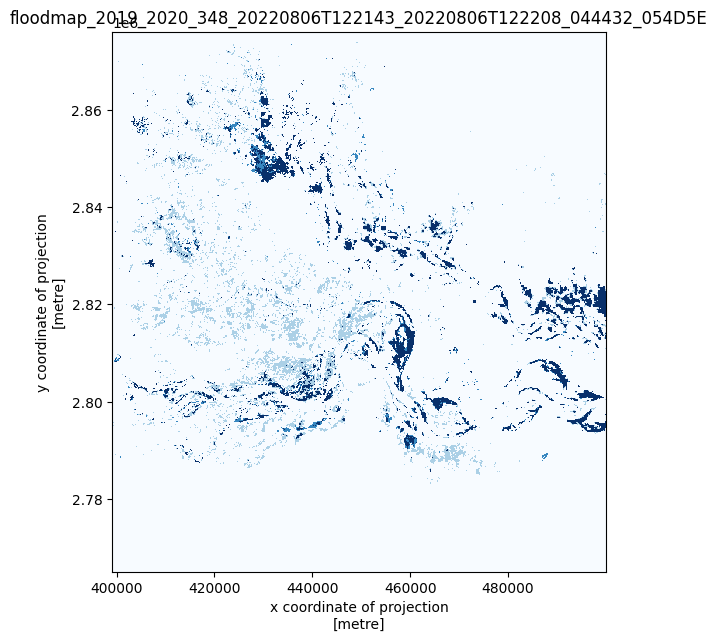

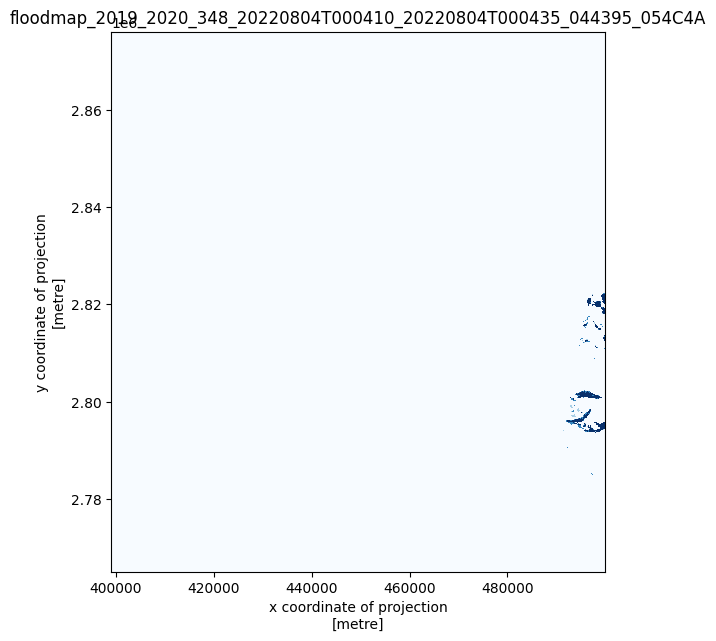

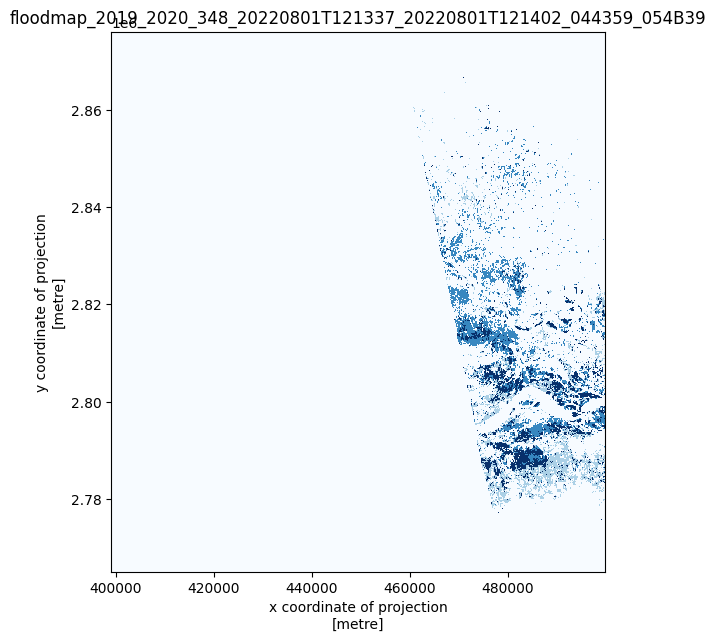

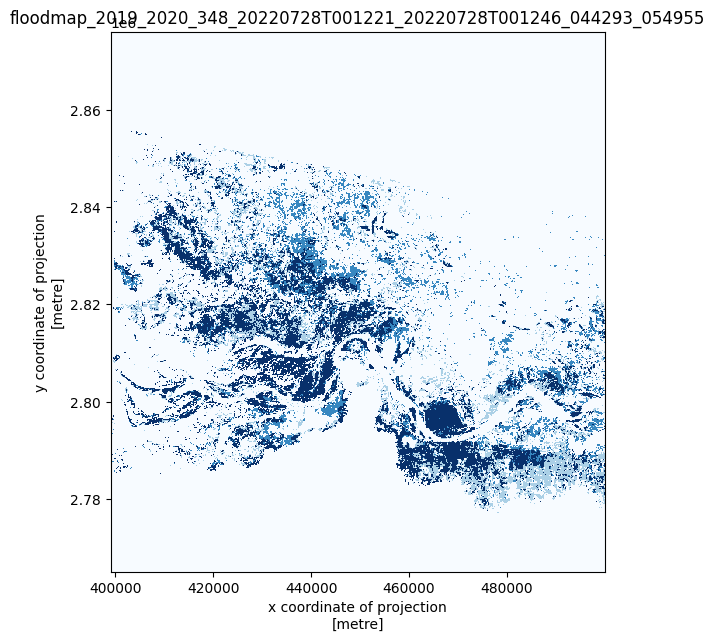

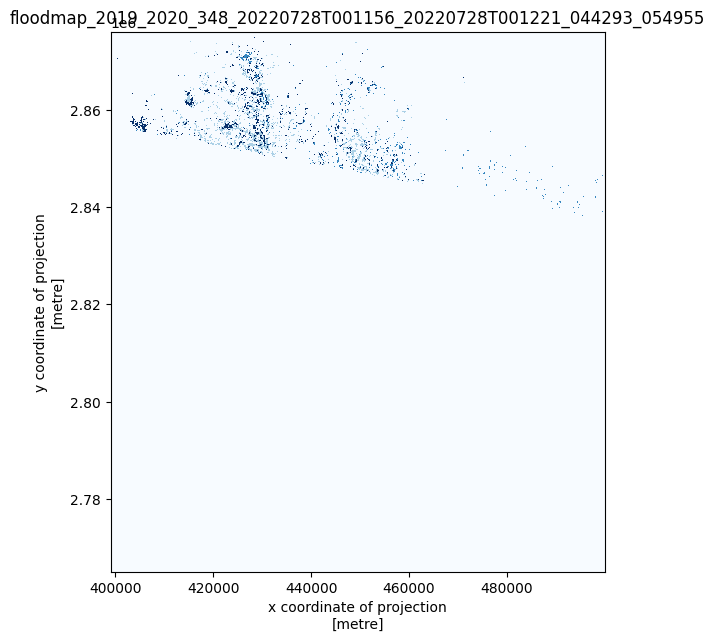

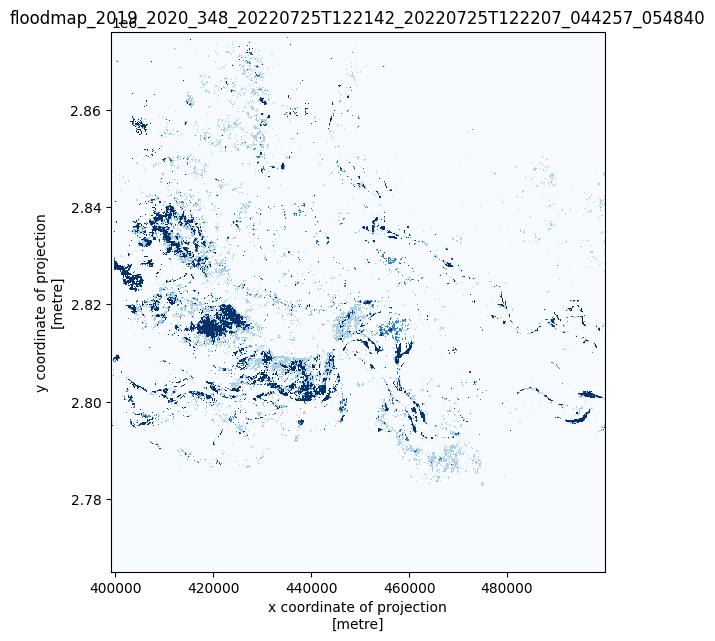

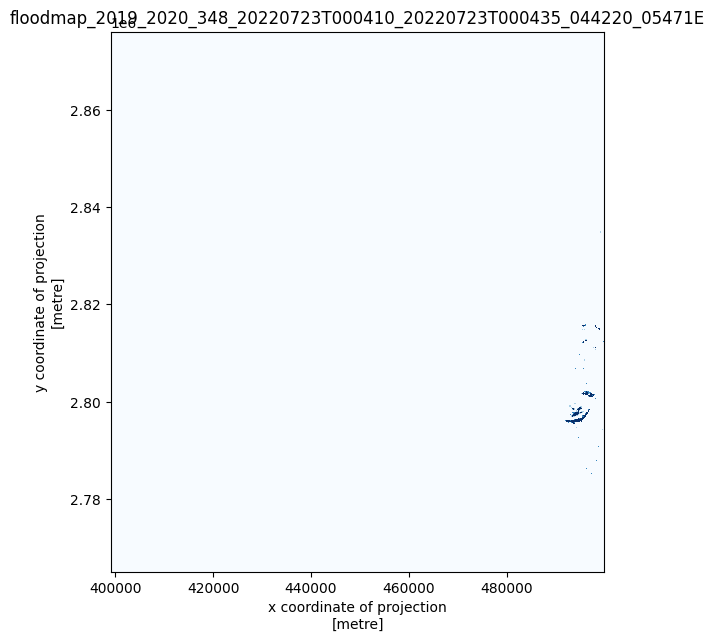

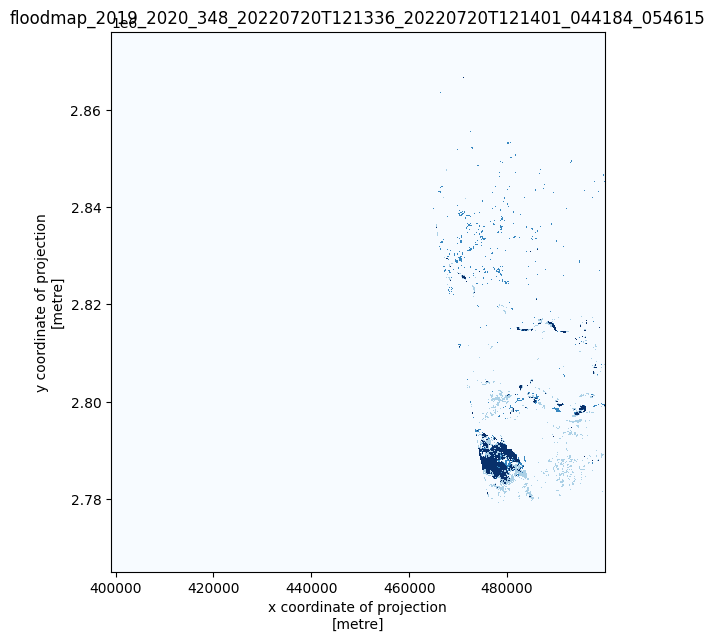

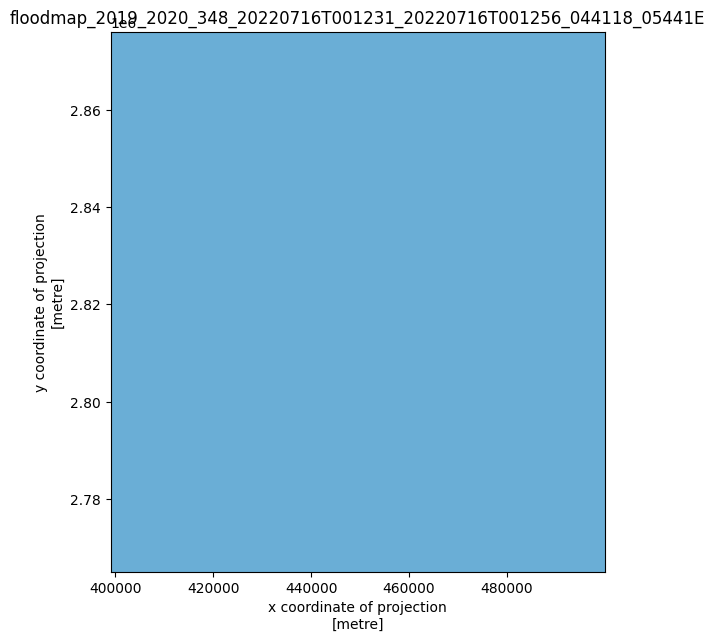

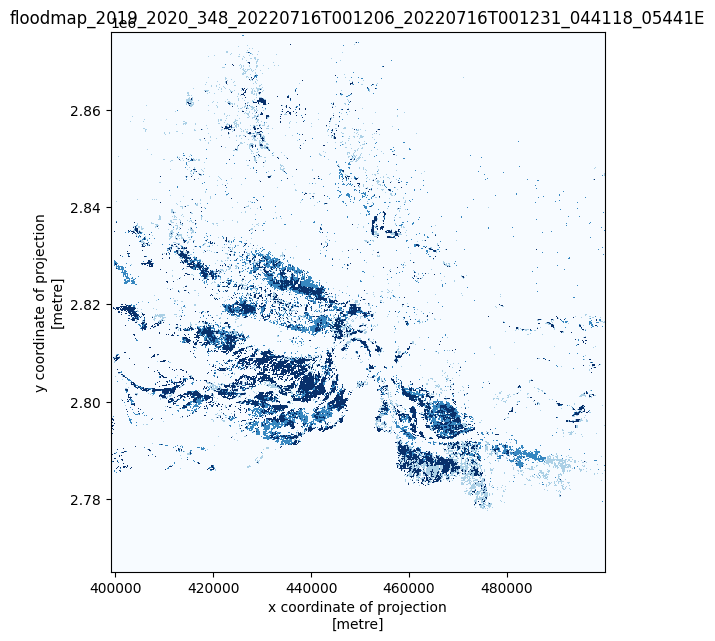

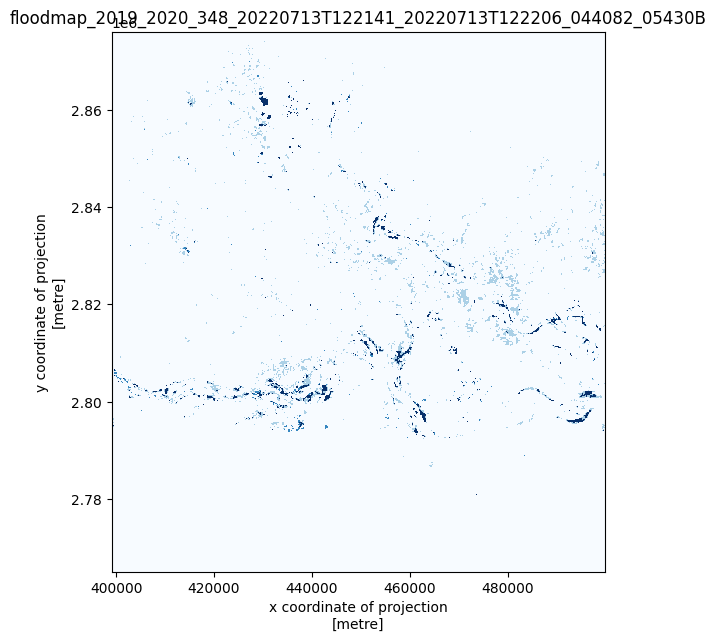

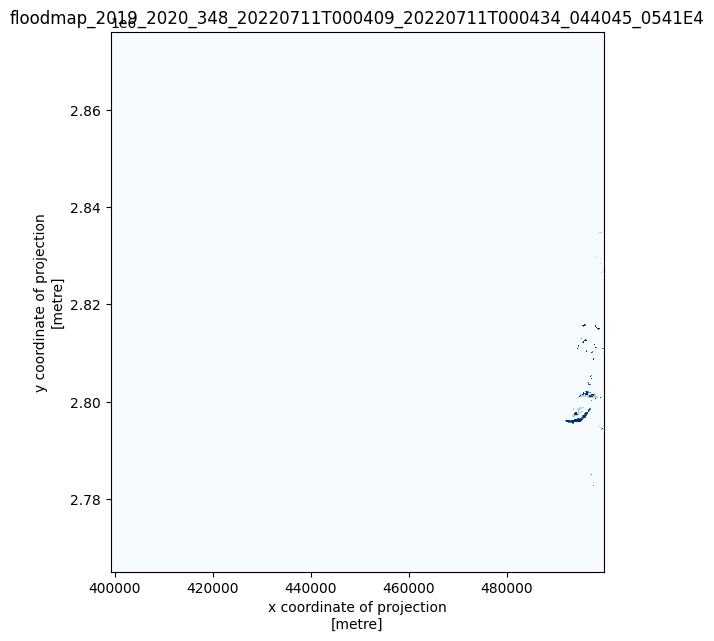

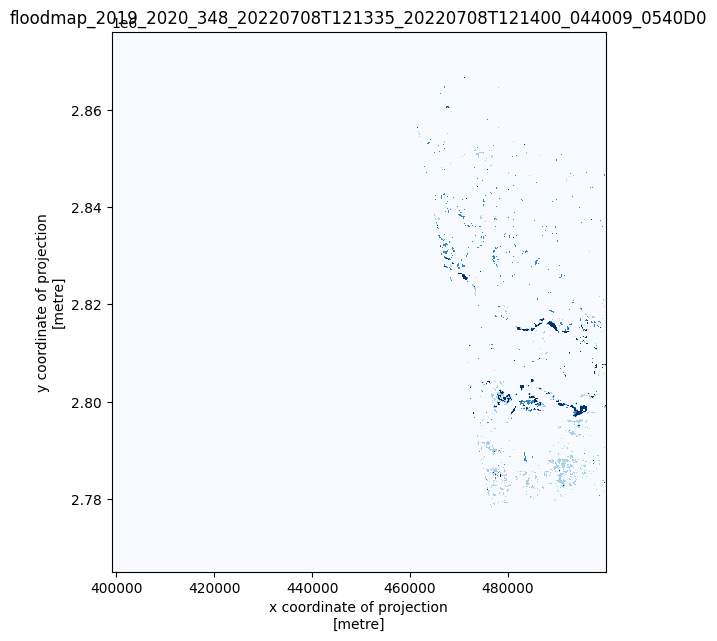

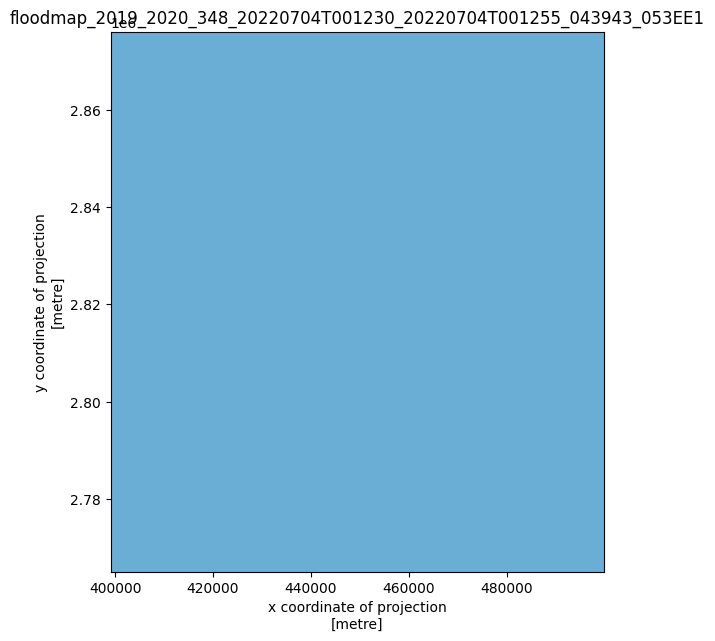

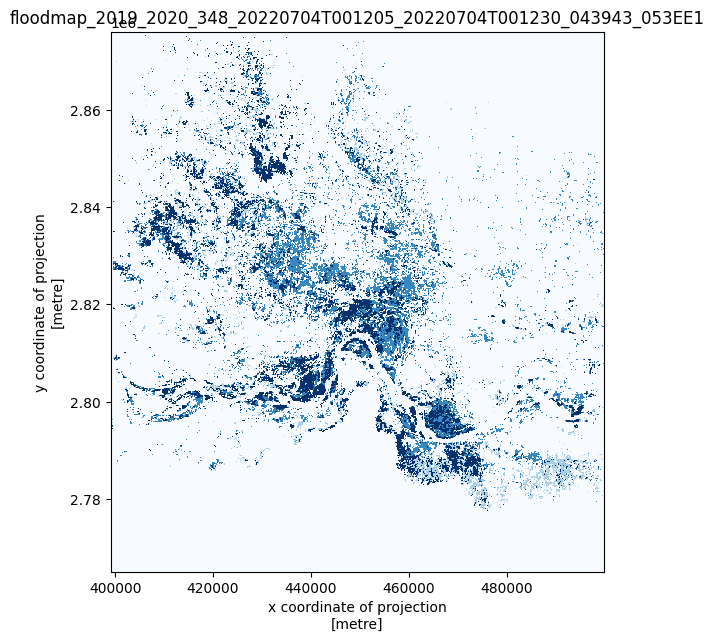

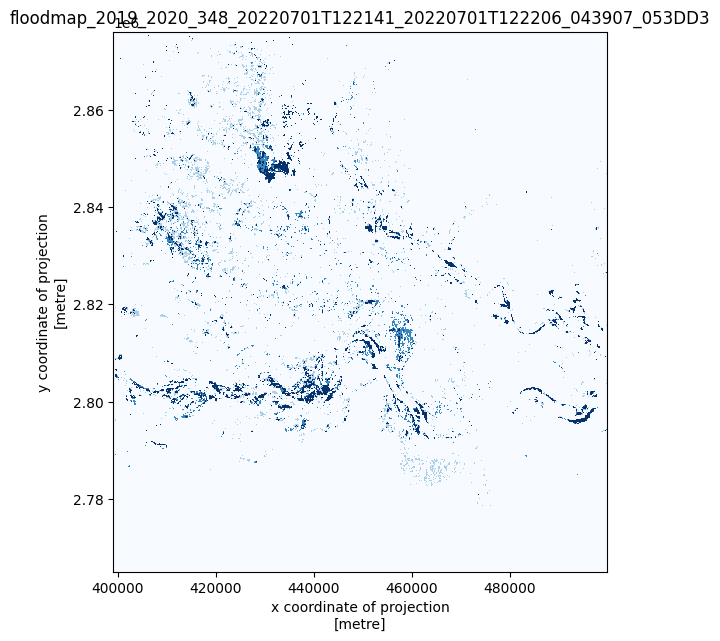

In [3]:
%%time
bihar_flood_mapper.get_dry_dates()

if len(bihar_flood_mapper.aoi_ids_to_process) > 0:
    bihar_flood_mapper.generate_dry_date_ranges()
    bihar_flood_mapper.get_s1_items(dry_wet='dry')
    bihar_flood_mapper.read_scenes(dry_wet='dry', overview_level=3)
    bihar_flood_mapper.generate_mean_std_by_aoi()
else:
    bihar_flood_mapper.load_mean_std_by_aoi()
    
bihar_flood_mapper.prepare_dem()
bihar_flood_mapper.prepare_wet_scenes(overview_level=3)
bihar_flood_mapper.map_floods(vv_thd=2.5, vh_thd=2.5, dem_thd=40, export_raster=False, export_vector=True, export_maps=True)

In [2]:
utils.merge_flood_gdfs(r'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/flood_vector')